In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns ; sns.set()

%matplotlib inline

In [2]:
jobs = pd.read_csv('csv_files/cleaned_list.csv')
print(jobs.shape)
print(jobs.nunique())
jobs.head()

(299, 30)
Job Title            140
Salary Estimate       10
Job Description      270
Rating                25
Company Name         230
Location             128
Headquarters         141
Size                   9
Founded               80
Type of ownership     12
Industry              44
Sector                21
Revenue               14
Competitors           52
hourly                 1
min_salary            10
max_salary            10
avg_salary             9
city                 126
state                 34
same_state             2
company_age           80
num_competitors        4
job_tag                5
job_level              3
State                 33
Region                 4
Division               9
Latitude              32
Longitude             33
dtype: int64


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,same_state,company_age,num_competitors,job_tag,job_level,State,Region,Division,Latitude,Longitude
0,Data Scientist,70-116,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,...,0,52,0,data scientist,none,Virginia,South,South Atlantic,38.003386,-79.458786
1,Data Scientist,70-116,"VA Boston Healthcare System\nBoston, Massachus...",3.6,VA Boston Healthcare System,"Boston, MA","Boston, MA",201 to 500 employees,-1,Hospital,...,1,-1,0,data scientist,none,Massachusetts,Northeast,New England,42.062940,-71.718067
2,Data & Analytics Consultant,70-116,WHO WE LOOK FOR\n\nAn SEI Consultant is a mast...,4.6,SEI,"Cincinnati, OH","Cincinnati, OH",201 to 500 employees,1992,Company - Private,...,1,28,0,other,none,Ohio,Midwest,East North Central,40.190362,-82.669252
3,R&D Scientist,70-116,"Since 2001, Hygiena has been on a mission to b...",3.9,Hygiena,"New Castle, DE","Camarillo, CA",201 to 500 employees,-1,Company - Private,...,0,-1,2,other,none,Delaware,South,South Atlantic,39.145251,-75.418921
4,Data Scientist,70-116,Why We Work at Dun & Bradstreet\n\n\nWe are at...,3.1,Dun & Bradstreet,"Austin, TX","Short Hills, NJ",1001 to 5000 employees,1841,Company - Private,...,0,179,2,data scientist,none,Texas,South,West South Central,31.169336,-100.076842


Text(0.5, 1.0, 'Histogram of Avg. Job Salaries')

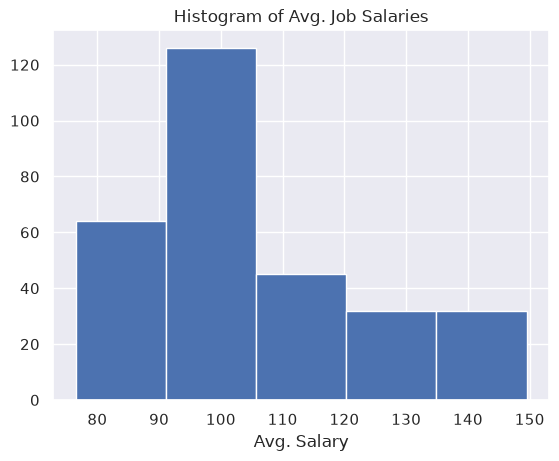

In [3]:
jobs.avg_salary.hist(bins=5)
plt.xlabel('Avg. Salary')
plt.title('Histogram of Avg. Job Salaries')

Text(0.5, 1.0, 'Histogram of Avg. Job Raitings')

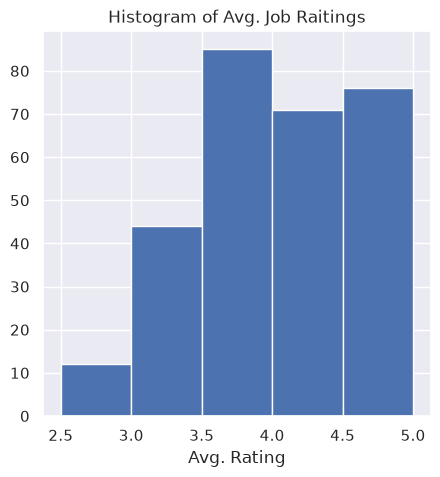

In [4]:
fig, ax = plt.subplots(figsize=(5,5))
jobs[jobs['Rating'] != -1].Rating.hist(bins=5)
ax.set_xlabel('Avg. Rating')
ax.set_title('Histogram of Avg. Job Raitings')

In [5]:
print(jobs['Size'].value_counts())
print(jobs['state'].value_counts())
print(jobs['job_tag'].value_counts())
print(jobs['job_level'].value_counts())

Size
51 to 200 employees        68
10000+ employees           62
1 to 50 employees          44
1001 to 5000 employees     39
201 to 500 employees       32
5001 to 10000 employees    22
501 to 1000 employees      21
Unknown                     8
-1                          3
Name: count, dtype: int64
state
CA    70
MA    27
NY    24
TX    21
VA    20
DC    13
WA    13
IL    10
PA     9
NJ     9
OH     8
MO     8
NC     6
MD     4
WI     4
FL     4
MI     4
CO     4
AL     3
AZ     3
GA     3
CT     3
NE     2
MN     2
UT     2
PR     2
DE     1
KY     1
KS     1
AR     1
TN     1
LA     1
IA     1
NM     1
Name: count, dtype: int64
job_tag
data scientist    237
other              44
data engineer      10
data analyst        5
mle                 3
Name: count, dtype: int64
job_level
none                   229
Experienced             56
Associate/Jr. Level     14
Name: count, dtype: int64


In [6]:
import plotly.graph_objects as go  # used to plot choropleth using plotly go

def choropleth_map(df, aggs,aggregation, locations, colors):  # given a data frame a list of intersted aggregations and color list 
    df = df.groupby('state')[aggs].agg(aggregation).reset_index()  # aggregate only plotted cols (pandas>=2 is strict)
    for color, agg in zip(colors, aggs):
        fig = go.Figure(data=go.Choropleth(locations=df[locations],
                                           z = df[agg].astype(float),
                                           locationmode= 'USA-states',
                                           colorscale = color,
                                           autocolorscale=False,
        #                                    text = df[agg], 
                                           marker_line_color = 'white'

                                          ))

        fig.update_layout(
            title_text='{0} {1} Per State'.format(aggregation, agg),
            geo = dict(
                scope='usa',
                projection=go.layout.geo.Projection(type = 'albers usa'),
                showlakes=True, # lakes
                lakecolor='rgb(255, 255, 255)'),
        )
        
        try:
            fig.write_image('images/{0} {1} Per State.png'.format(aggregation, agg))  # plotly's way of saving a static image
        except Exception as e:
            print('  (could not save static image: {})'.format(e))

        fig.show()
#         return df.head()



In [7]:
# df_state = jobs.groupby('state').mean(numeric_only=True).reset_index()
choro_groups = ['Rating', 'Founded', 'min_salary', 'max_salary', 'avg_salary', 'company_age', 'num_competitors']
colors = ['Tealgrn' for group in choro_groups]  # Tealgrn for all

choropleth_map(jobs, choro_groups, 'mean', 'state', colors)  # plotting multiple graphs and saving into our folder


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


In [8]:
# choropleth_map(df_state, ['avg_salary', 'max_salary'], 'state', ['blues', 'reds'])
# choropleth_map(df_state, )

choro_groups = ['Rating', 'Founded', 'min_salary', 'max_salary', 'avg_salary', 'company_age', 'num_competitors']
# testing different colors
# colors = ['Darkmint', 'Tealgrn', 'PuBu', 'PuBuGn', 'Greens', 'Bugn', 'Mint', 'Blugrn', 'Teal', 'Tealgrn', 'Darkmint' ] 
colors = ['Tealgrn' for group in choro_groups]  # Tealgrn I like for all

choropleth_map(jobs, choro_groups,'mean', 'state', colors )  # plotting mutliple graphs and also saving into our folder

# for group, color in zip(choro_groups, colors):
#     choropleth_map(df_state, group, 'state', color )


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


  (could not save static image: Error 525: unexpected error while fetching topojson file at https://cdn.plot.ly/un/usa_110m.json)


In [9]:
print('Jobs Per Region \n')
display(jobs['Region'].value_counts())

Jobs Per Region 



Region
West         93
South        79
Northeast    72
Midwest      40
Name: count, dtype: int64

In [10]:
# since value counts seem to be similar we can create histogrmas to make sure they're about normal and the run a/b tests on the regions

jobs.groupby('Region').mean(numeric_only=True)

,Rating,Founded,hourly,min_salary,max_salary,avg_salary,same_state,company_age,num_competitors,Latitude,Longitude
Region,,,,,,,,,,,
Midwest,3.762500,1778.250000,0.0,81.350000,119.925000,100.637500,0.300000,39.550000,0.575000,41.014881,-89.466624
Northeast,3.797222,1668.069444,0.0,82.013889,126.208333,104.111111,0.486111,43.013889,0.500000,41.214293,-73.627708
South,3.640506,1429.797468,0.0,79.949367,124.075949,102.012658,0.291139,27.113924,0.316456,35.102428,-85.521143
West,3.997849,1716.752688,0.0,85.301075,131.247312,108.274194,0.440860,20.602151,1.021505,37.488010,-112.228318


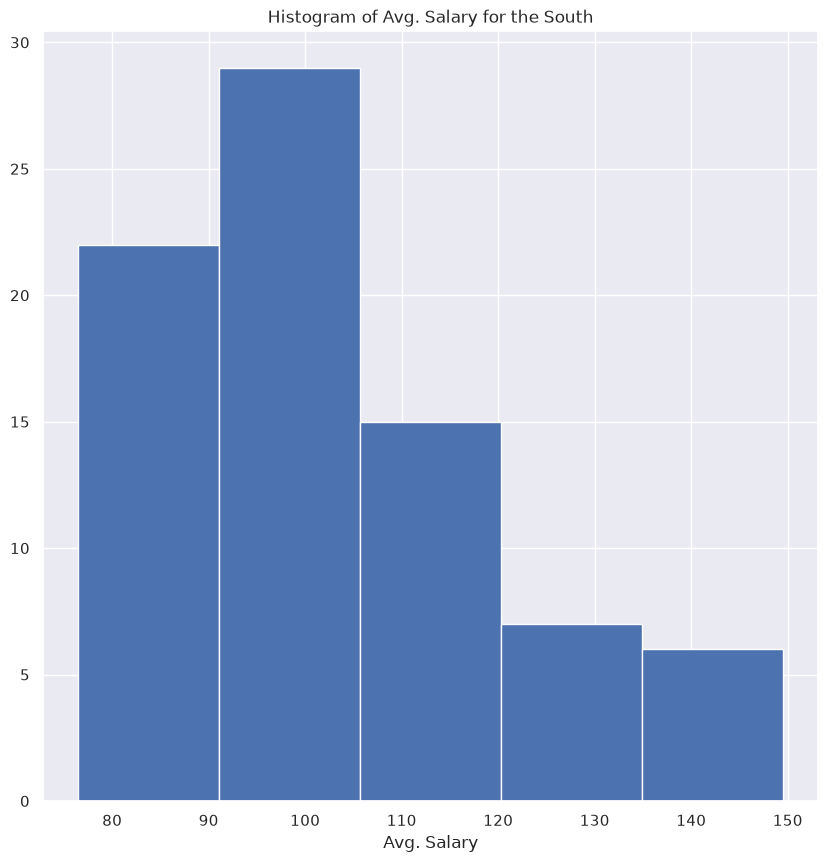

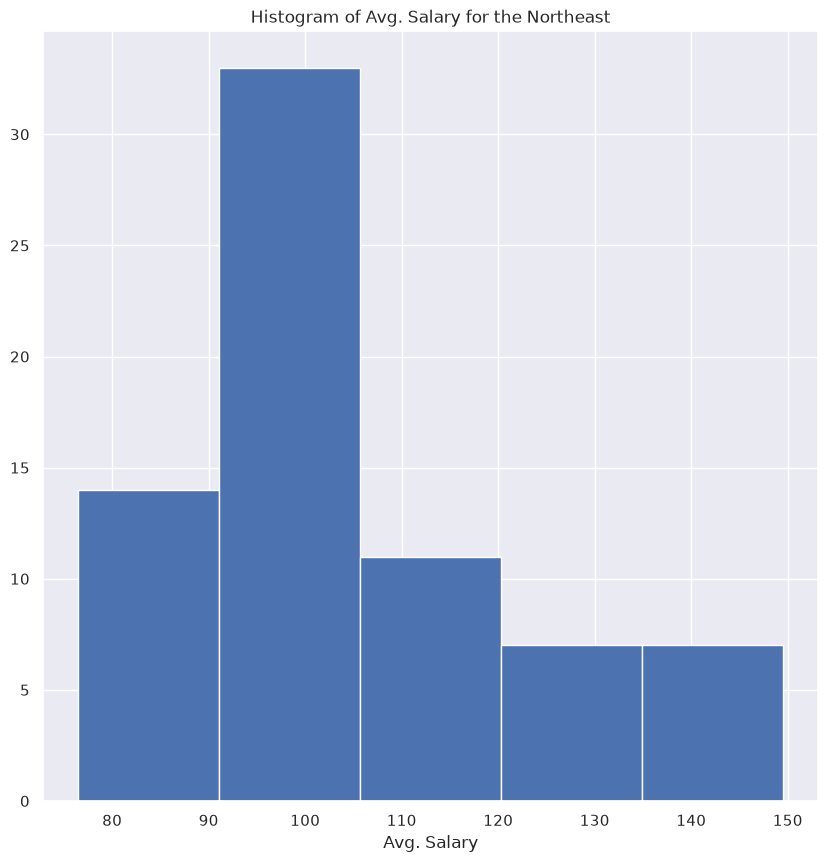

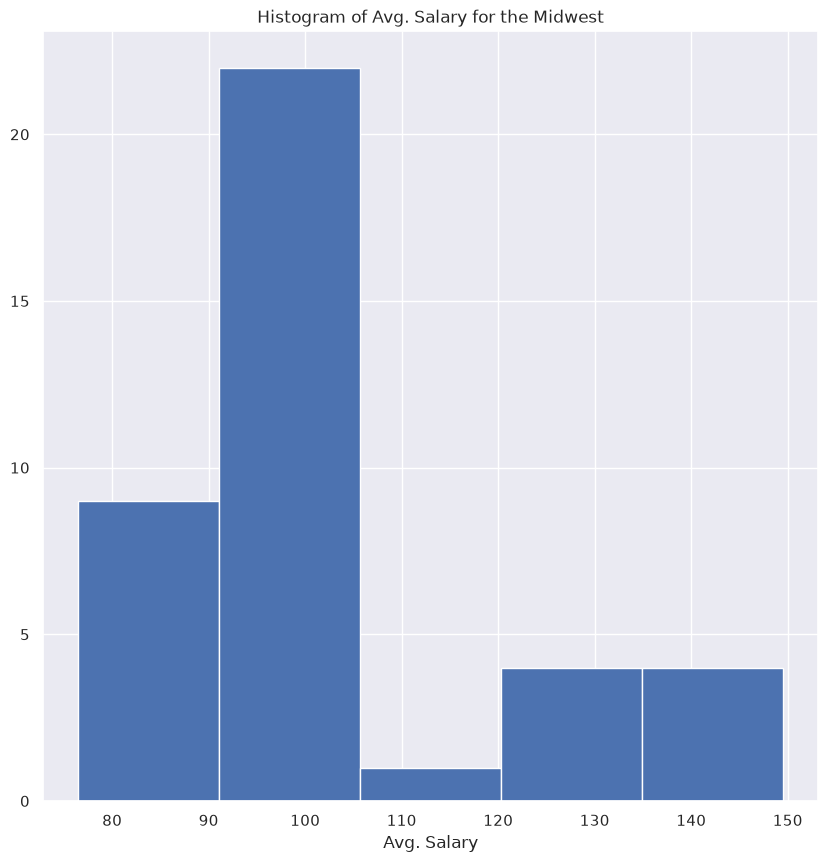

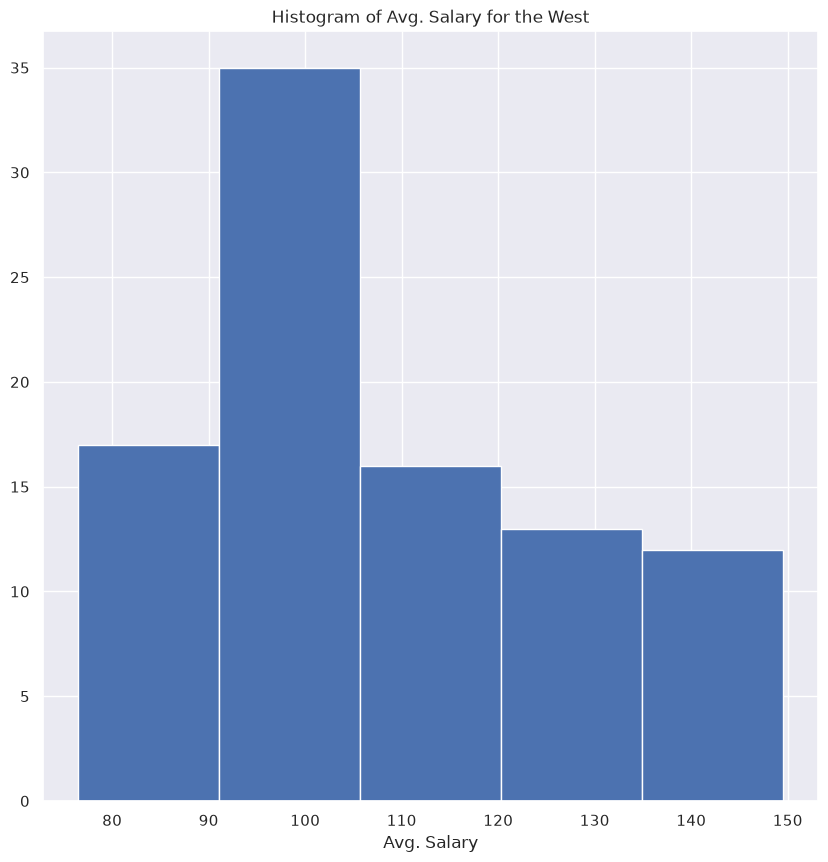

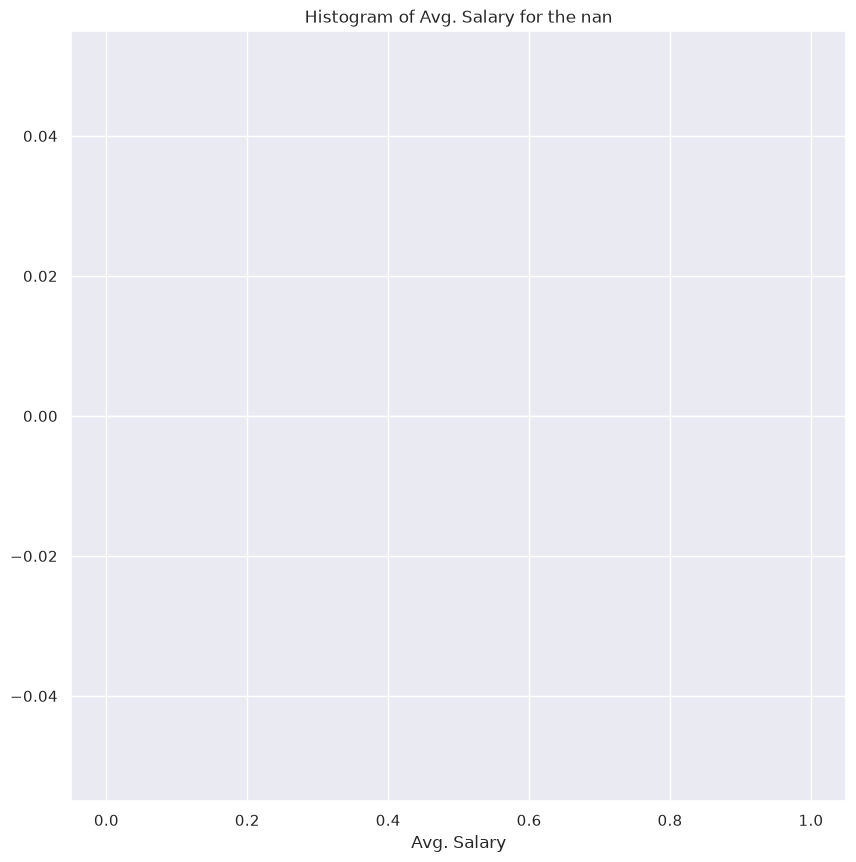

In [11]:
uniq_region = jobs.Region.unique()

for reg in uniq_region:
    temp = jobs[jobs['Region']==reg]
#     print(reg)
    fig, ax = plt.subplots(figsize=(10,10))
    chart = temp.avg_salary.hist(bins=5)
    ax.set_xlabel('Avg. Salary')
    title = 'Histogram of Avg. Salary for the {}'.format(reg)
    ax.set_title(title)
    plt.savefig('images/histograms/'+title+'.png')
    plt.show()
#     print(reg)


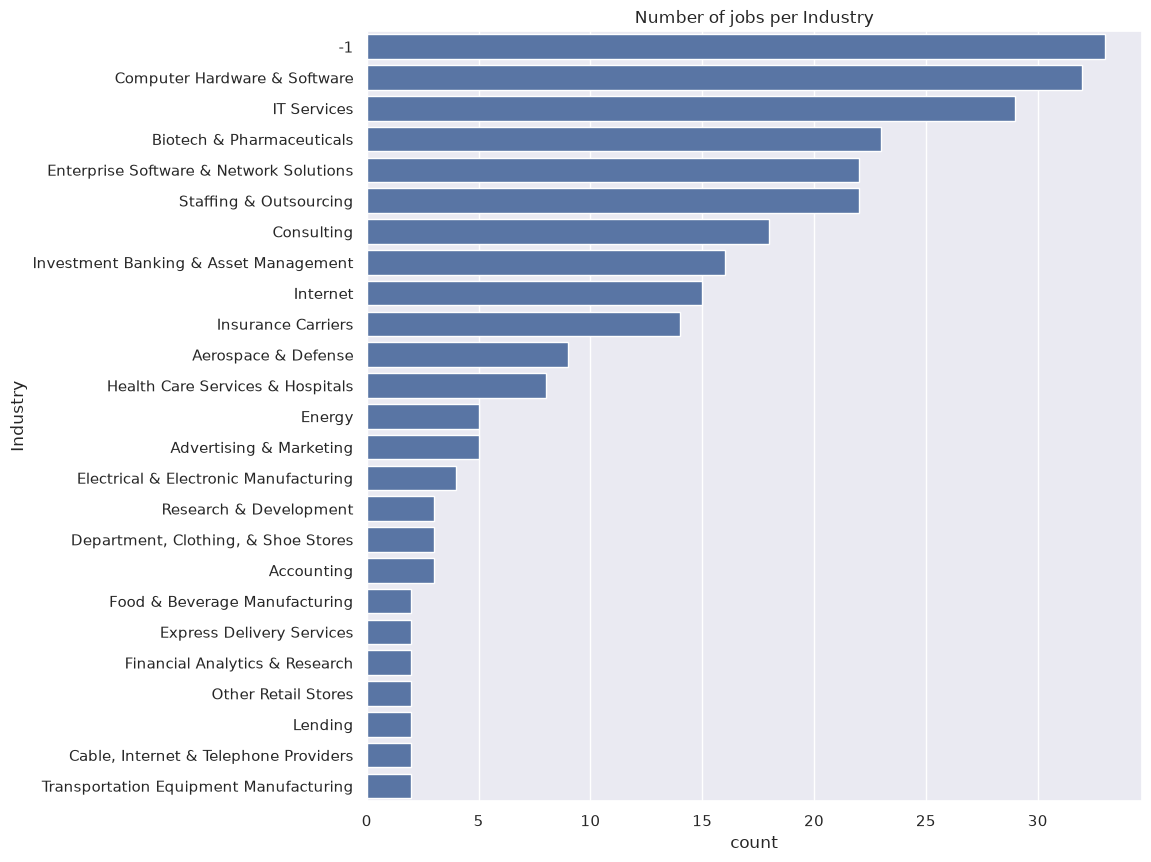

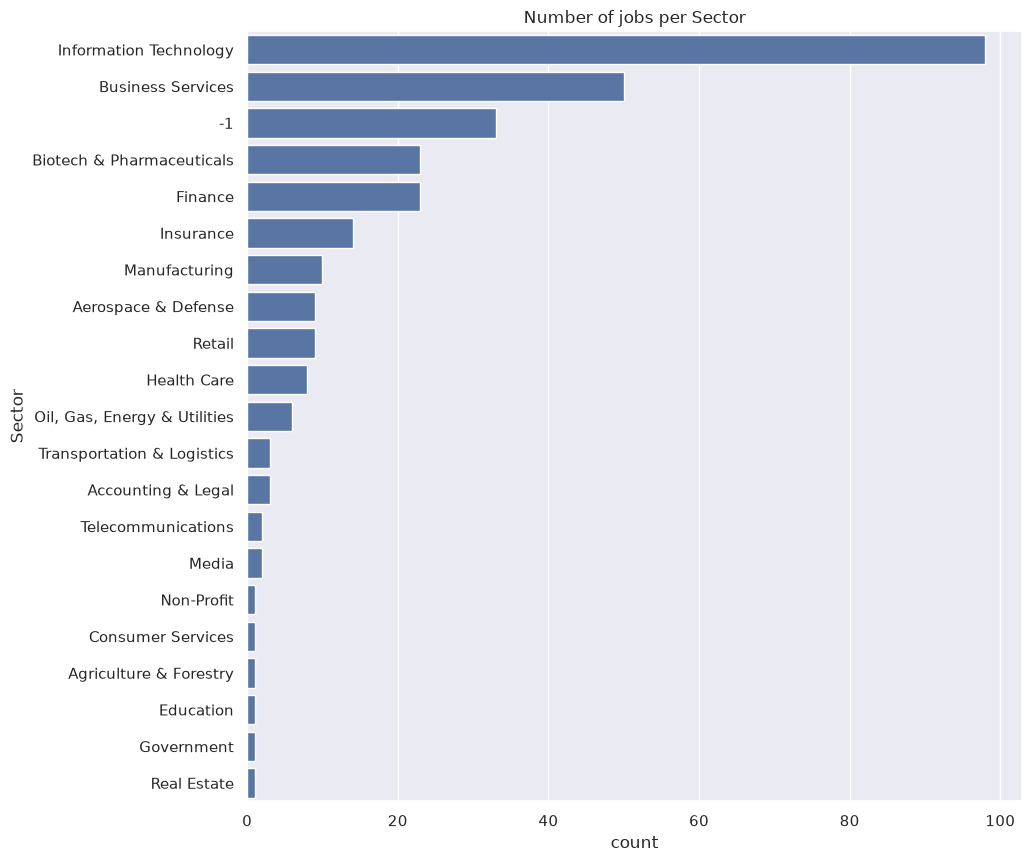

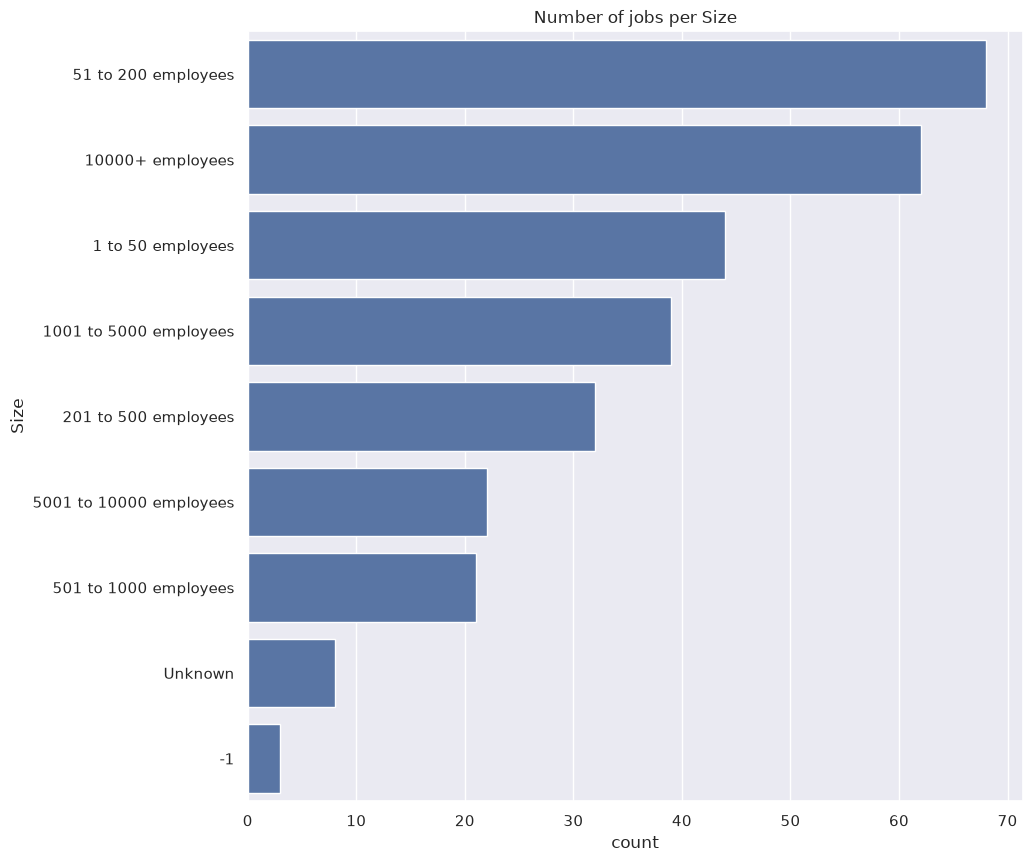

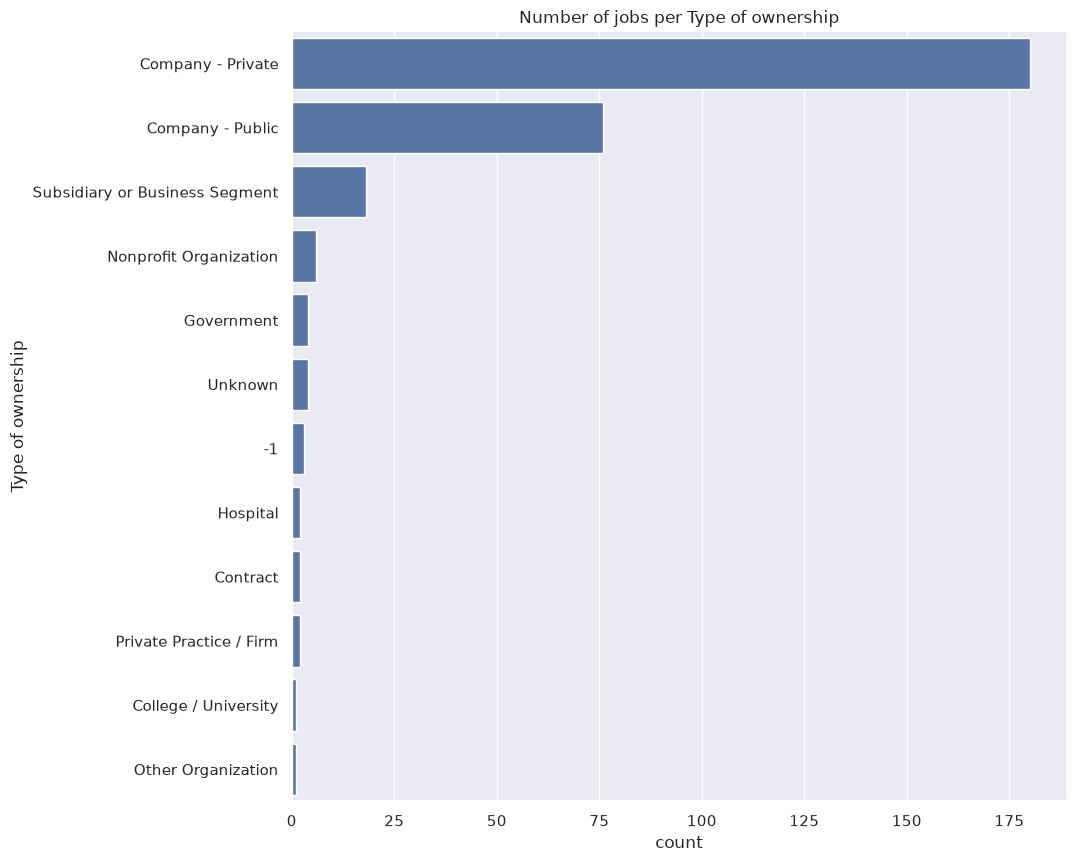

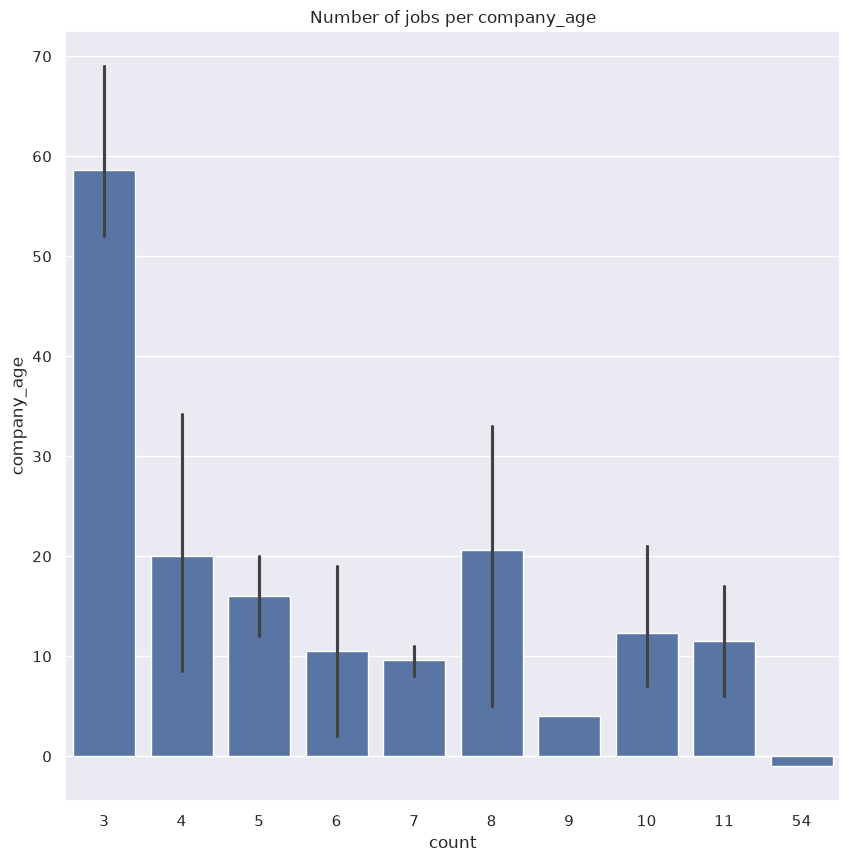

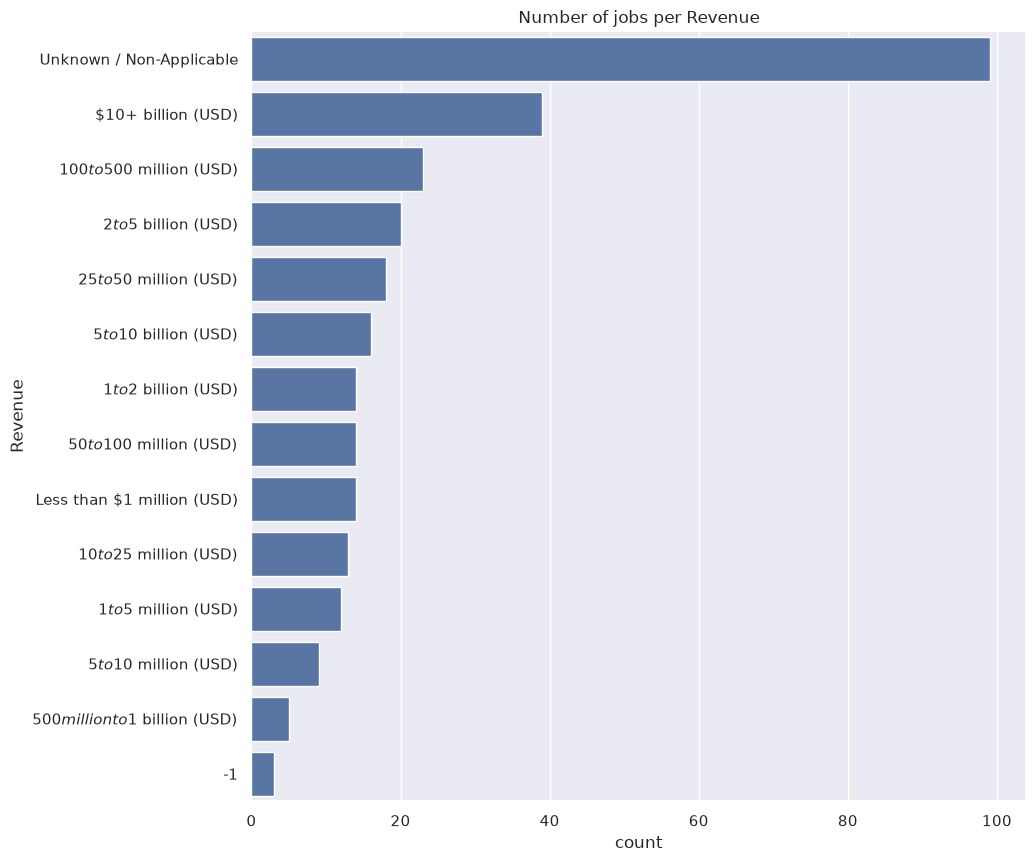

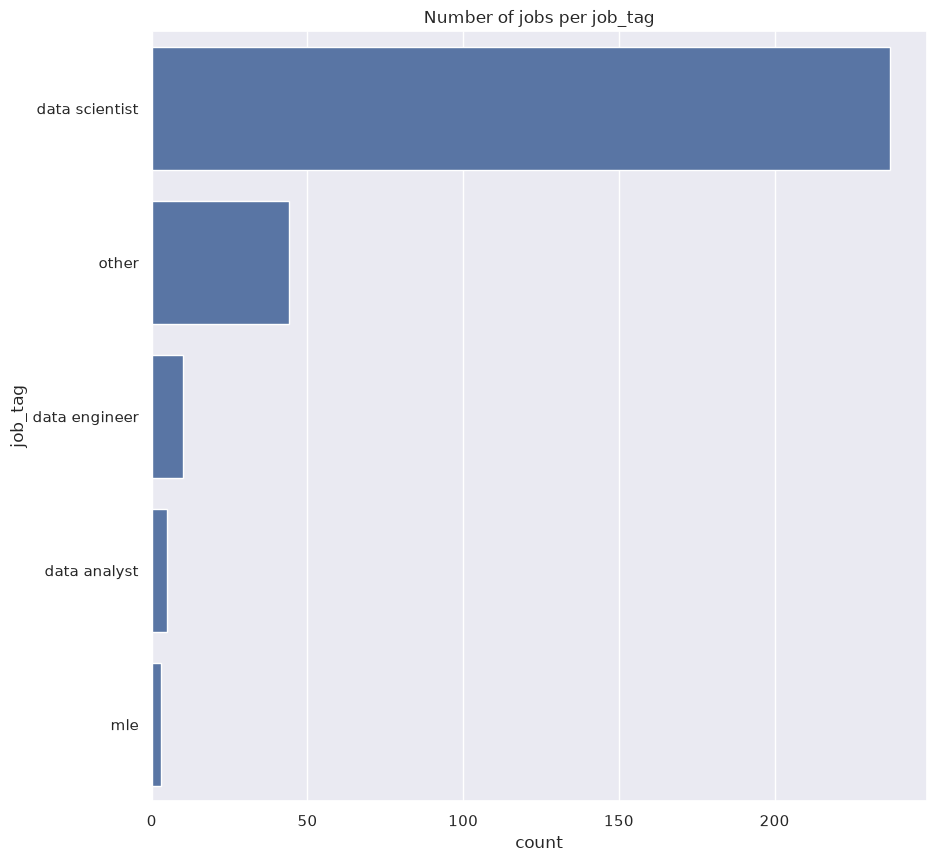

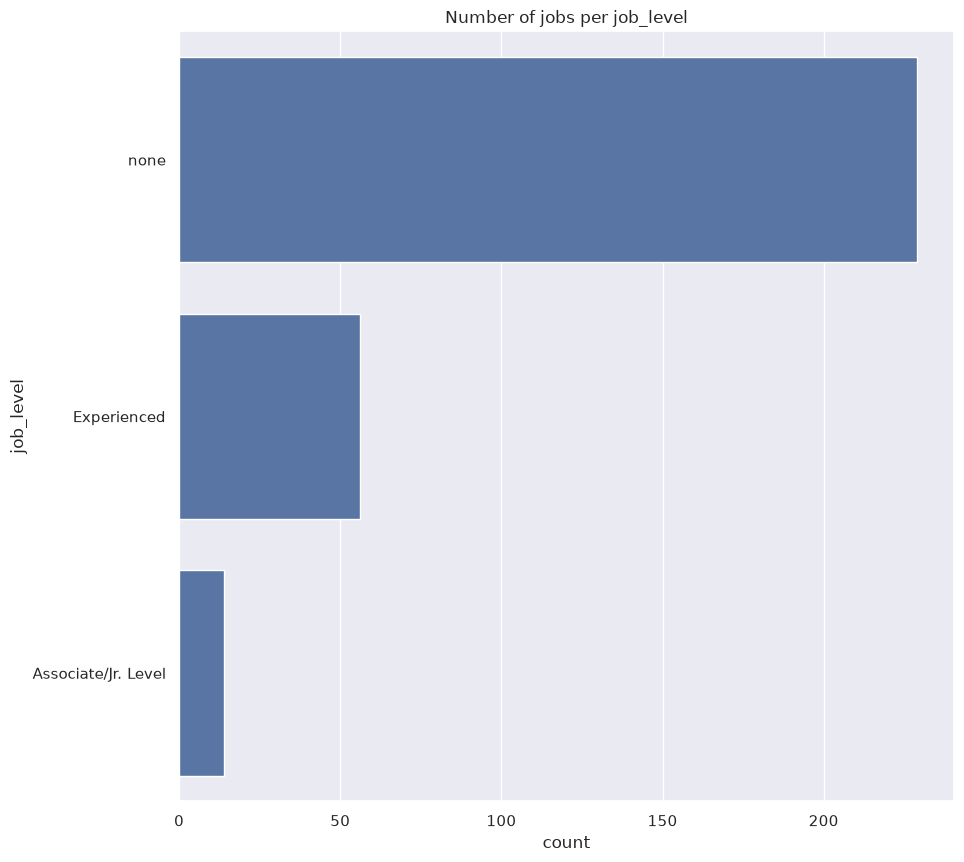

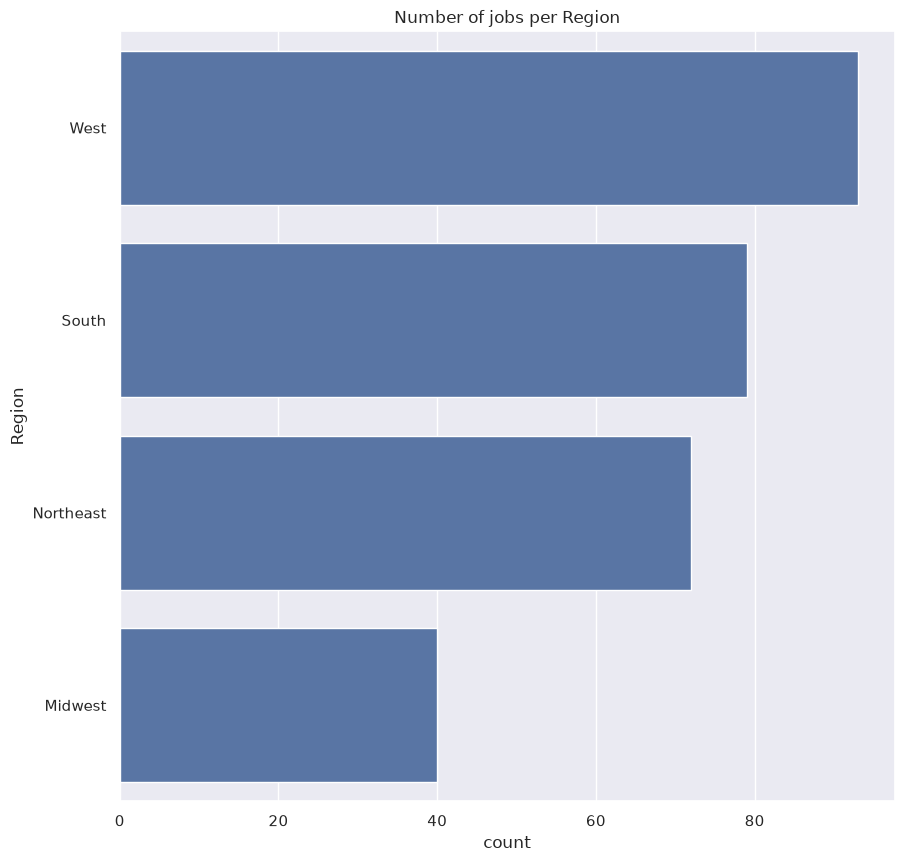

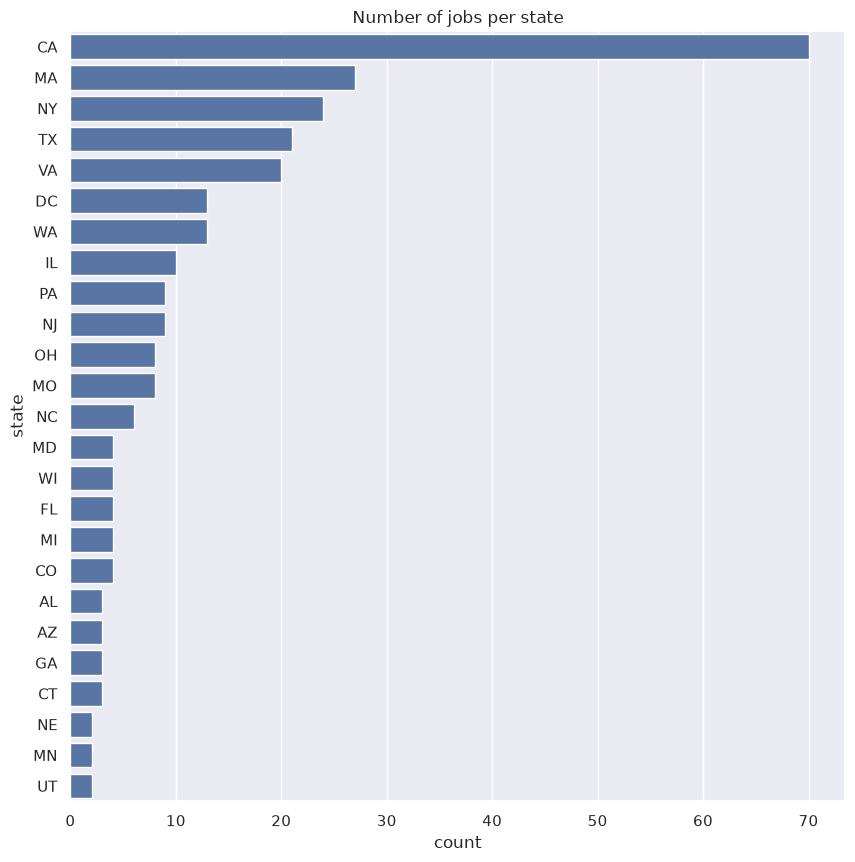

In [12]:
jobs_cat = jobs[['Industry','Sector', 'Size', 'Type of ownership', 'company_age', 'Revenue', 'job_tag', 'job_level', 'Region', 'state']]
sns.set()
for cat in jobs_cat.columns:
    fig, ax = plt.subplots(figsize = (10,10))
    temp = jobs[cat].value_counts()[:25]
#     print(cat)
    graph = sns.barplot(y=temp.index, x=temp, color='b', ax=ax)
    ax.set_title('Number of jobs per {}'.format(cat))
    fig.savefig('images/histograms/Number of jobs per' + cat)
    plt.show()

In [13]:
# # WordCloud - Used for generating a word cloud 

# from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
# from nltk.corpus import stopwords
# from nltk.tokenize import word_tokenize

# # cleaning our job description col
# def remove_punct(text):
#     words_tokenized = []
#     stop_words = set(stopwords.words('english'))
#     word_tokens = word_tokenize(text)
    
#     for word in word_tokens:
#         if word not in stop_words and word.isalpha():
#             words_tokenized.append(word.lower())
#     return(words_tokenized)

# words = ' '.join(jobs['Job Description'])
# words = remove_punct(words)


In [14]:
# text = ' '.join(word for word in words)  # creating large block of words for wordcloud

# wc = WordCloud(background_color='white', stopwords=STOPWORDS, width=1600, height=800)
# wc.generate(text)

# plt.figure(figsize=(10,10))
# plt.imshow(wc, interpolation='bilinear')
# plt.axis('off')
# plt.show()

In [15]:
north_east = jobs[jobs['Region']== 'Northeast']
west = jobs[jobs['Region']== 'West']
south_east = jobs[jobs['Region']== 'Southeast']
mid_west = jobs[jobs['Region']== 'Midwest']
south_west = jobs[jobs['Region']== 'Southwest']

regions = ['north_east', 'west', 'south_east','mid_west','south_west']

<Axes: >

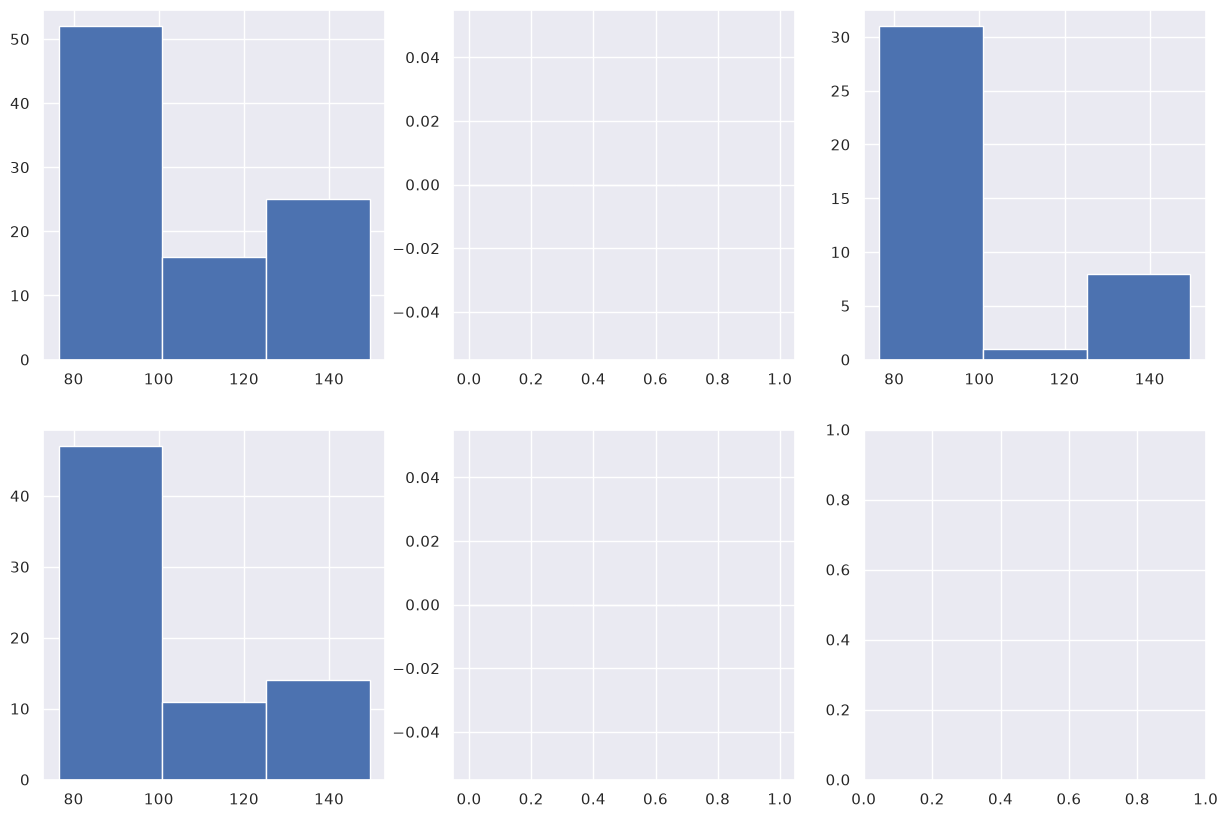

In [16]:
# more histograms

fig, ax = plt.subplots(2,3, figsize=(15,10))
west.avg_salary.hist(bins=3, ax=ax[0,0])
north_east.avg_salary.hist(bins=3, ax= ax[1,0])
south_east.avg_salary.hist(bins=3, ax=ax[0,1])
south_west.avg_salary.hist(bins=3, ax=ax[1,1])
mid_west.avg_salary.hist(bins=3, ax=ax[0,2])

In [17]:
import scipy.stats as stats


In [18]:
stats.ttest_ind(jobs[jobs['Region']== 'NorthEast'].avg_salary, 
               jobs[jobs['Region']== 'West'].avg_salary, equal_var=True)

/tmp/ipykernel_12637/4084244529.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.ttest_ind(jobs[jobs['Region']== 'NorthEast'].avg_salary,


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [19]:
stats.ttest_ind(jobs[jobs['Region']== 'NorthEast'].avg_salary, 
               jobs[jobs['Region']== 'SouthEast'].avg_salary, equal_var=False)

/tmp/ipykernel_12637/2883499606.py:1: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.ttest_ind(jobs[jobs['Region']== 'NorthEast'].avg_salary,


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [20]:
# jobs.to_csv('eda_cleaned_data.csv', index=False)

In [21]:
jobs.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'min_salary', 'max_salary', 'avg_salary', 'city', 'state',
       'same_state', 'company_age', 'num_competitors', 'job_tag', 'job_level',
       'State', 'Region', 'Division', 'Latitude', 'Longitude'],
      dtype='str')

### T test Scatter Plots

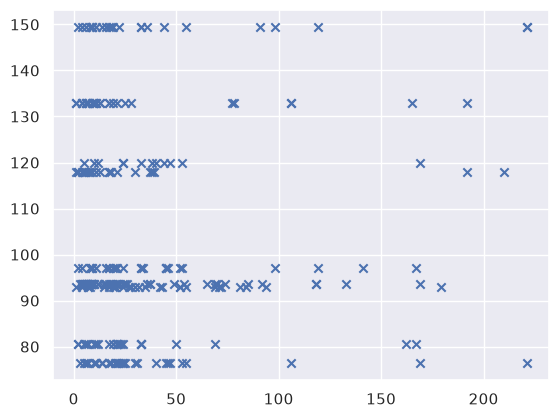

In [22]:
plt.scatter(jobs[jobs['company_age'] >= 0].company_age, jobs[jobs['company_age'] >= 0].avg_salary, marker='x')

In [23]:
jobs[jobs['company_age'] >= 0]

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,same_state,company_age,num_competitors,job_tag,job_level,State,Region,Division,Latitude,Longitude
0,Data Scientist,70-116,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,...,0,52,0,data scientist,none,Virginia,South,South Atlantic,38.003386,-79.458786
2,Data & Analytics Consultant,70-116,WHO WE LOOK FOR\n\nAn SEI Consultant is a mast...,4.6,SEI,"Cincinnati, OH","Cincinnati, OH",201 to 500 employees,1992,Company - Private,...,1,28,0,other,none,Ohio,Midwest,East North Central,40.190362,-82.669252
4,Data Scientist,70-116,Why We Work at Dun & Bradstreet\n\n\nWe are at...,3.1,Dun & Bradstreet,"Austin, TX","Short Hills, NJ",1001 to 5000 employees,1841,Company - Private,...,0,179,2,data scientist,none,Texas,South,West South Central,31.169336,-100.076842
5,"Scientist, Pharmacology",70-116,Sutro has a unique capability that enables new...,4.3,Dun & Bradstreet,"Austin, TX","South San Francisco, CA",51 to 200 employees,2003,Company - Public,...,0,17,0,other,none,Texas,South,West South Central,31.169336,-100.076842
6,Sr. Data Scientist,70-116,Sr. Data Scientist\nCurative is scaling up COV...,4.0,"Curative Inc,","San Dimas, CA","Racine, WI",51 to 200 employees,1949,Nonprofit Organization,...,0,71,0,data scientist,Experienced,California,West,Pacific,37.271875,-119.270415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,Lead Data Scientist,92-148,"Job Description\n\nSince 1851, MassMutuals com...",3.7,MassMutual,"Boston, MA","Springfield, MA",5001 to 10000 employees,1851,Company - Private,...,0,169,0,data scientist,Experienced,Massachusetts,Northeast,New England,42.062940,-71.718067
294,"Video Business Data Scientist, Apple Media Pro...",92-148,"Posted: Jun 22, 2020\nRole Number:\n200172948\...",4.1,Apple,"Culver City, CA","Cupertino, CA",10000+ employees,1976,Company - Public,...,0,44,3,data scientist,none,California,West,Pacific,37.271875,-119.270415
295,Data Scientist,92-148,"Data Scientist\nLocation: Hill AFB, UT\nEducat...",3.8,Tecolote Research,"Hill AFB, UT","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,0,47,0,data scientist,none,Utah,West,Mountain,39.499761,-111.547028
296,Data Scientist,92-148,Role: Data Science | Machine Learning\nWork Lo...,4.0,SOFTHQ INC,"Austin, TX","San Diego, CA",51 to 200 employees,2010,Company - Private,...,0,10,0,data scientist,none,Texas,South,West South Central,31.169336,-100.076842


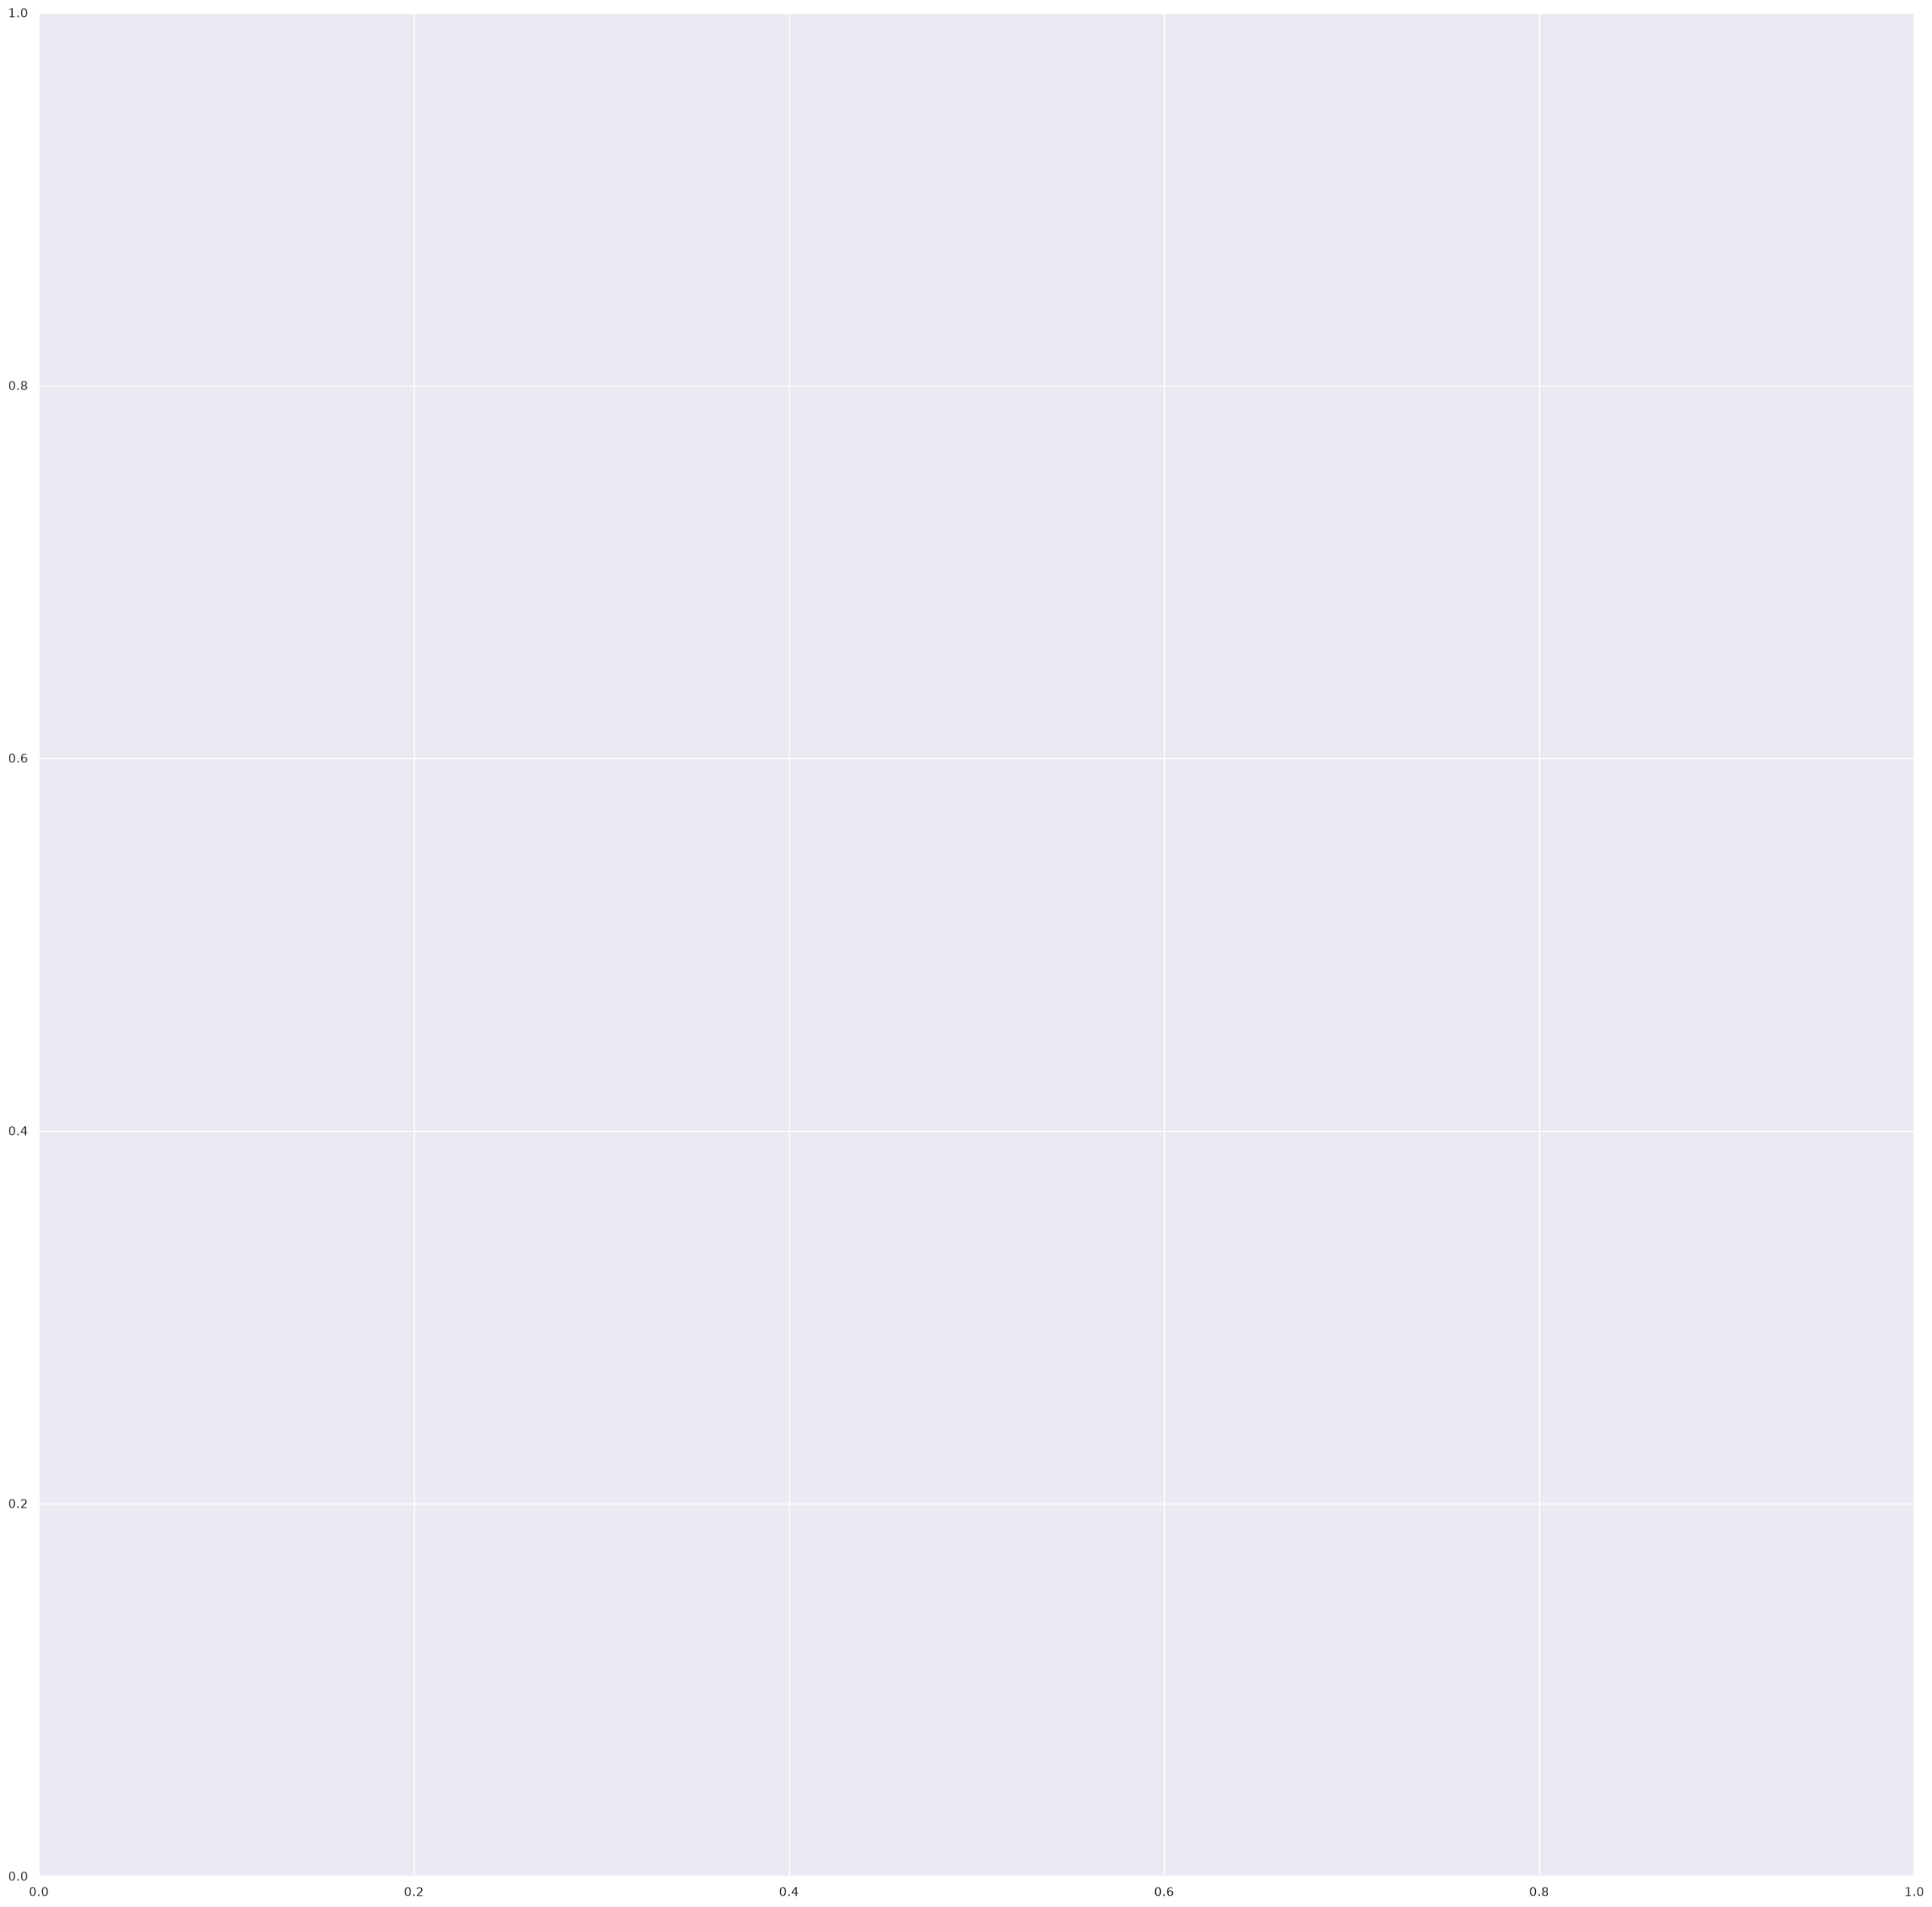

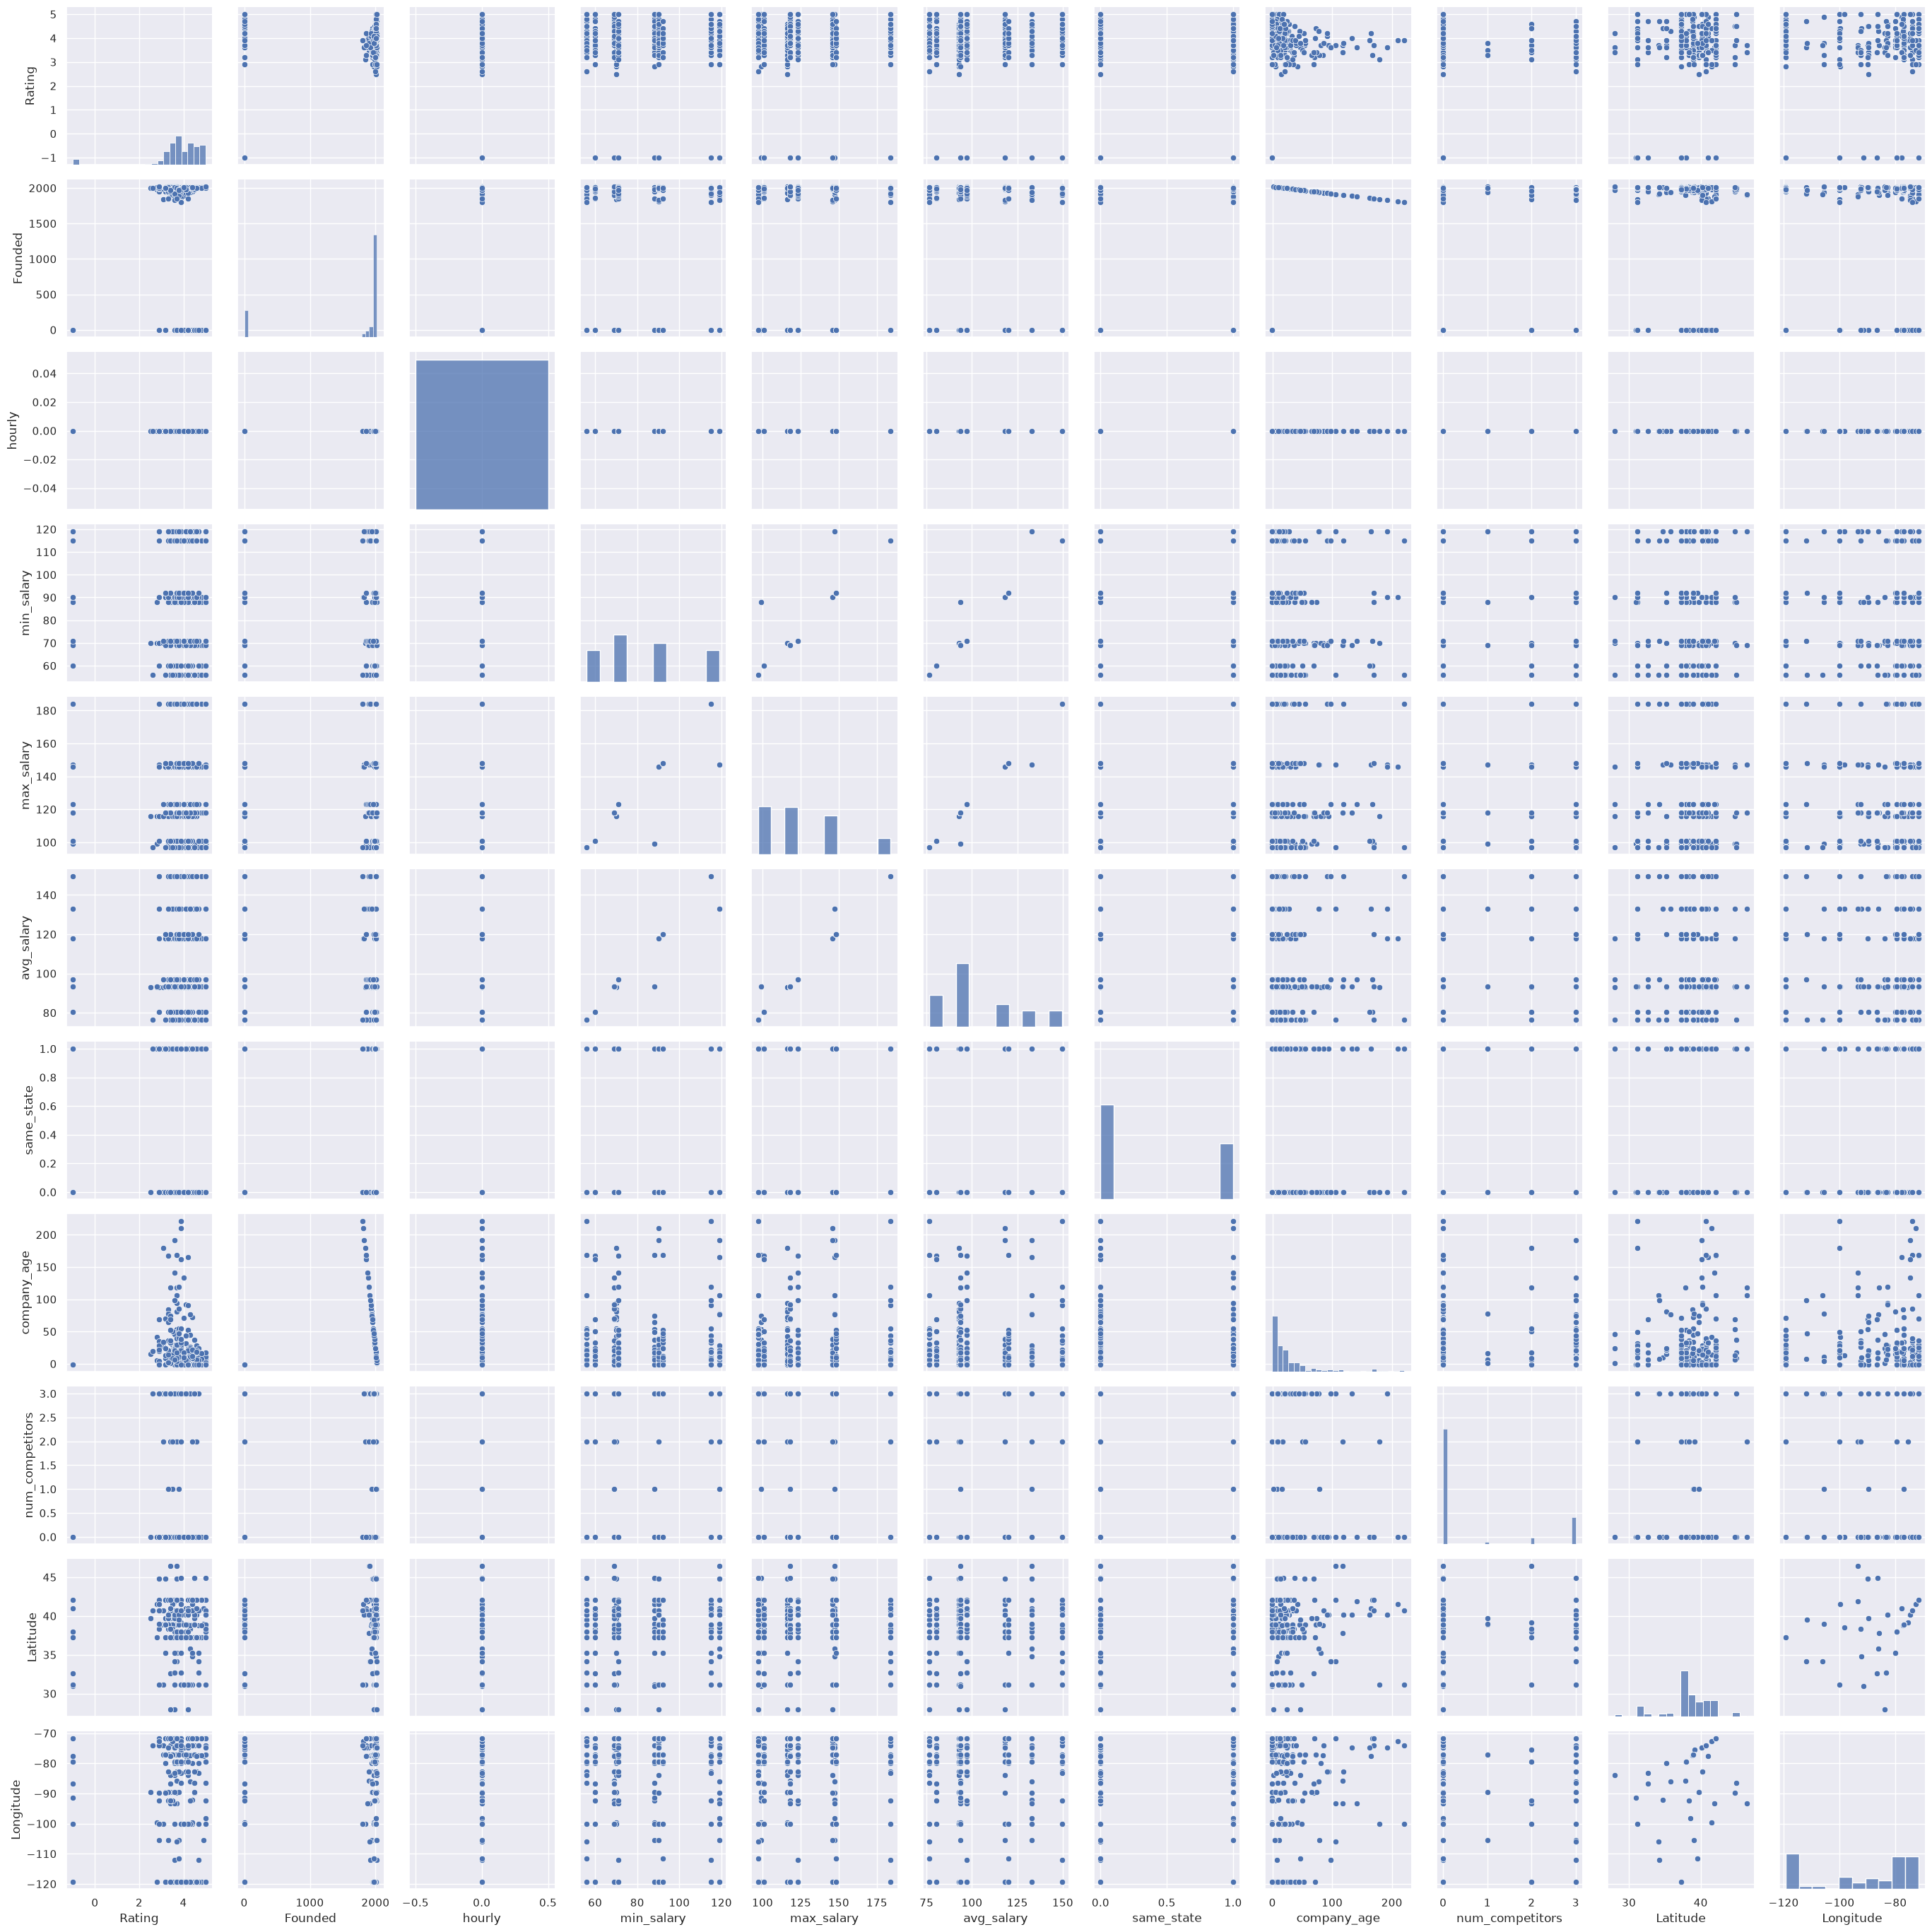

In [24]:
fig, ax = plt.subplots(figsize=(30,30))
sns.pairplot(jobs)
# fig = jobs_pairplot.figure
plt.tight_layout()
plt.savefig('images/large_pairplot.png')
# plt.show()